# Imports

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import glob
import math
import time
import subprocess
import os
from IPython.display import clear_output
from matplotlib import cm
CMAP = cm.summer


from analysis import *
from sim_funcs import *

# Processing the simulation data 

In [2]:
fname = "flux_rates_full_moon_1000"
consolidate_sims(fname)
thetas, phis, flux = read_flux_file(fname)



In [3]:
np.size(flux)

1000

# Figures

In [4]:
x,y,z = fibonacci_sphere(samples=10000)
r,phi_fill,theta_fill = conv_cart_to_sph(x,y,z)
impact_fill = interp_impact_rates(np.degrees(phi_fill), np.degrees(theta_fill), fname)
theta_fill = theta_fill-np.pi
phi_fill=((phi_fill-0.5*np.pi)*-1.0)


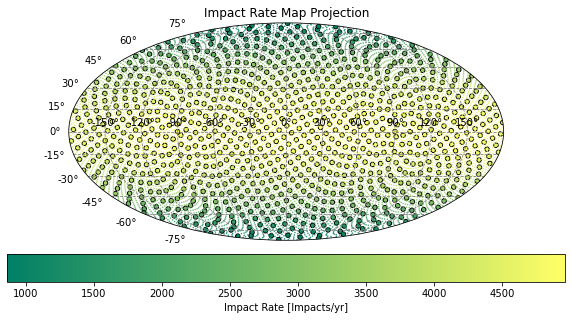

In [5]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection="mollweide")

theta_rad = np.radians(thetas-180)
phi_rad = np.radians((phis-90)*-1.0)
colors = CMAP((flux-np.min(flux))/(np.max(flux)-np.min(flux)))

plt.scatter(theta_rad, phi_rad, c=flux, cmap=CMAP, s=20,edgecolor="black")
plt.scatter(theta_fill,phi_fill, c=impact_fill, cmap=CMAP, s=0.25)
cbar = plt.colorbar(orientation="horizontal", pad=0.05)
cbar.set_label("Impact Rate [Impacts/yr]")

ax.grid(True, linestyle="--", color="gray")
plt.title("Impact Rate Map Projection")
plt.savefig("figures/impacts_full_moon_min_mass.pdf", bbox_inches="tight")

# Interpolation and measuring impacts near the proposed lunar bases

In [7]:


theta_base = np.radians([77.0, 0.0, 210.0, 220.0, 270.0, 260.0, 250.0, 356.6, 0.0, 45.0, 40.0, 42.0, 85.0])
phi_base = np.radians(np.array([-87.4, -89.8, -89.5, -89.2, -88.5, -88.7, -88.2, -87.6, -85.8, -84.9, -86.7, -86.5, -84.4])*-1+90)
name_base = ["Faustini Rim A", "Peak Near Shackleton", "Connecting Ridge", "Connecting Ridge Extension", "de Gerlache Rim 1","de Gerlache Rim 2", "de Gerlache-Kocher Massif", "Haworth", "Malapert Massif", "Leibnitz Beta Plateau", "Nobile Rim 1", "Nobile Rim 2", "Amundsen Rim"]
impact_base = []
for x in range(len(theta_base)):
    rate = interp_impact_rates(phi_base[x], theta_base[x], fname)
    impact_base.append(float(rate))
ind = np.argmin(impact_base)
safest = name_base[ind]
print("The safest proposed base location is at " +safest + " with an impact rate of " + str(impact_base[ind]) +" impacts/yr")
print("The impact rates at the other bases:", list(impact_base))


The safest proposed base location is at Haworth with an impact rate of 1077.9038757954888 impacts/yr
The impact rates at the other bases: [1131.856379162283, 1149.5159949567471, 1105.6074268116358, 1103.5342656525206, 1093.7435089526562, 1095.6950053749083, 1097.3661822420306, 1077.9038757954888, 1147.755395468079, 1137.600390440717, 1139.4622287489533, 1138.9440156602338, 1128.8634740613147]


# Checking velocity distribution

In [11]:
sims = np.sort(get_all_sim_dirs())
print(sims[0])
pull_phi_theta(sims[0])

C:/Users/Matthew/Dropbox/github_repos/lunar_impacts/MEM3_Windows/data_1000_m6\phi_1.139_theta_194.582


(1.139, 194.582)

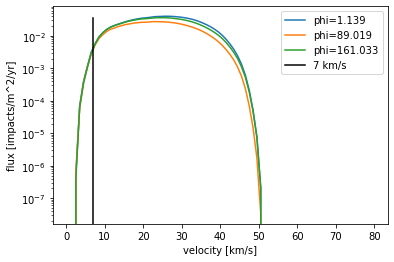

In [17]:
for x in [0,900,400]:
    df = get_cube_avg(sims[x])
    v = df["velocity"].values
    phi=str(pull_phi_theta(sims[x])[0])
    f = ((df["+x"]+df["-x"]+df["+y"]+df["-y"]+df["+z"]).values)/5
    plt.plot(v,f, label="phi="+phi)
plt.xlabel("velocity [km/s]")
plt.ylabel("flux [impacts/m^2/yr]")
plt.plot([7,7], [np.min(f), np.max(f)], label="7 km/s", color="black")
plt.legend()

plt.yscale("log")
plt.savefig("figures/vel_dist.pdf", bbox_inches="tight")

# double checking that the velocity vectors are tangent to the positions in the trajectory file

In [38]:
sims = np.sort(get_all_sim_dirs())
print(sims[920])
df = pd.read_csv(sims[920]+"/trajectory.txt",skiprows=6,delim_whitespace=True,names=["d", "x", "y", "z", "vx", "vy", "vz"])
df["x"]*df["vx"]+df["y"]*df["vy"]+df["z"]*df["vz"]

C:/Users/Matthew/Dropbox/github_repos/lunar_impacts/MEM3_Windows/data_1000_m6\phi_91.189_theta_307.063


0     1.015559e-13
1     7.122081e-14
2    -1.038388e-13
3    -4.127081e-14
4    -8.247136e-14
5     4.748155e-14
6     7.481776e-14
7     9.944476e-14
8     6.418328e-14
9     2.339313e-14
10   -1.359989e-13
11   -1.080611e-13
12    2.468753e-14
13    6.923374e-14
14   -3.462692e-14
15    3.793604e-14
16   -1.136294e-13
17   -3.650726e-14
18   -5.336530e-14
19    4.964865e-14
20    8.439777e-14
21    4.773092e-14
22    9.062282e-14
23    6.395665e-14
24   -1.506234e-13
25   -7.557843e-14
26    1.061163e-17
27    5.505362e-14
28   -1.237985e-14
29    9.978129e-14
dtype: float64

In [39]:
W_MOON*R_MOON/SEC_PER_DAY

0.004735899313640033

In [41]:
np.sqrt(df["vx"]**2 + df["vy"]**2 + df["vz"]**2)

0     0.004735
1     0.004735
2     0.004735
3     0.004735
4     0.004735
5     0.004735
6     0.004735
7     0.004735
8     0.004735
9     0.004735
10    0.004735
11    0.004735
12    0.004735
13    0.004735
14    0.004735
15    0.004735
16    0.004735
17    0.004735
18    0.004735
19    0.004735
20    0.004735
21    0.004735
22    0.004735
23    0.004735
24    0.004735
25    0.004735
26    0.004735
27    0.004735
28    0.004735
29    0.004735
dtype: float64